# Telecom Customer Churn Prediction — End-to-End Machine Learning Project

**Placement-focused classification project**

### Objective
Predict whether a telecom customer is likely to churn and identify customer/service factors associated with churn.

### ML workflow
1. Business understanding
2. Data loading and quality checks
3. Univariate and bivariate EDA
4. Missing-value handling
5. Outlier analysis
6. Feature engineering
7. Encoding and scaling
8. Train/test split
9. Baseline model comparison
10. Cross-validation
11. Hyperparameter tuning
12. Final model selection using training CV
13. Threshold optimization using training CV
14. Final evaluation on unseen test data
15. Feature importance and business interpretation

> **Design choice:** PCA and a separate bias-variance experiment were not included because they were not necessary for this dataset/problem. The project focuses on techniques that directly support the churn-prediction objective.


In [1]:
# Install / import libraries
# XGBoost is usually pre-installed in Colab; this keeps the notebook robust.
!pip -q install xgboost

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV, cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.base import clone
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")


## 1. Load the dataset

The notebook uses the publicly available **IBM Telco Customer Churn** dataset. The CSV is loaded directly from a public GitHub mirror so the notebook can run in Google Colab without requiring a Kaggle API key.

If the URL ever becomes unavailable, download the same dataset manually and replace the `pd.read_csv()` line with the uploaded file path.


In [5]:
DATA_URL = "https://raw.githubusercontent.com/IBM/watsonx-ai-samples/master/cpd4.5/data/customer_churn/WA_FnUseC_TelcoCustomerChurn.csv"

df = pd.read_csv(DATA_URL)

print("Shape:", df.shape)
display(df.head())


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Basic structure
df.info()

print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:")
display(df["Churn"].value_counts(dropna=False))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count
Churn,
No,5174
Yes,1869


## 2. Data cleaning and initial quality checks

`TotalCharges` is stored as text in the original dataset because some rows contain blank strings. We convert it to numeric, turning invalid blanks into missing values.

We do **not** fill missing values before the train/test split. The final ML pipeline performs imputation using training data only, which helps prevent data leakage.


In [7]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("Missing percentage:")
display((df.isna().mean() * 100).sort_values(ascending=False).to_frame("missing_pct"))


Missing values:


,missing_count
TotalCharges,11
gender,0
SeniorCitizen,0
Partner,0
customerID,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0


Missing percentage:


,missing_pct
TotalCharges,0.156183
gender,0.000000
SeniorCitizen,0.000000
Partner,0.000000
customerID,0.000000
Dependents,0.000000
tenure,0.000000
MultipleLines,0.000000
PhoneService,0.000000
OnlineSecurity,0.000000


In [8]:
# Target conversion
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Churn rate:", round(df["Churn"].mean() * 100, 2), "%")


Churn rate: 26.54 %


## 3. Univariate EDA

The goal is not to create every possible graph. We focus on variables that can explain customer behavior and churn.


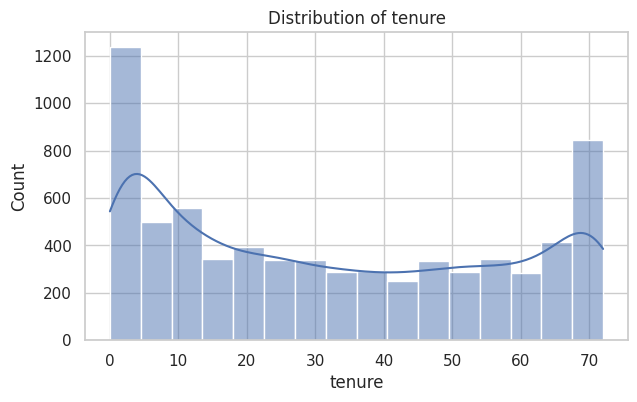

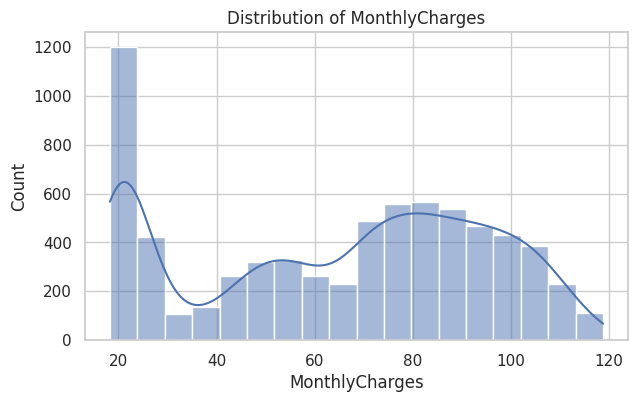

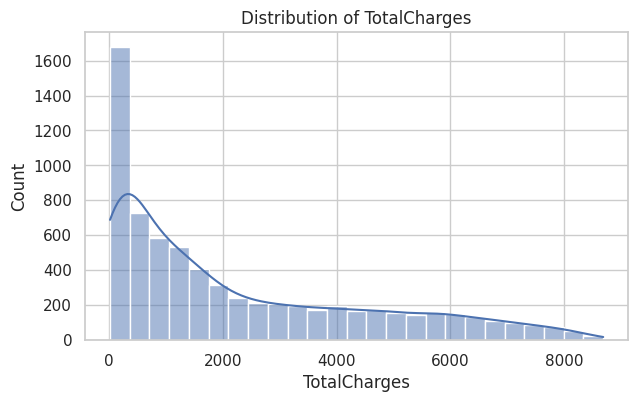

In [9]:
numeric_for_eda = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_for_eda:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


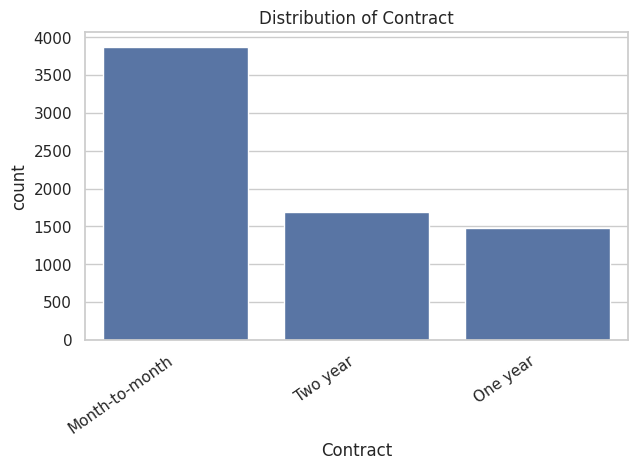

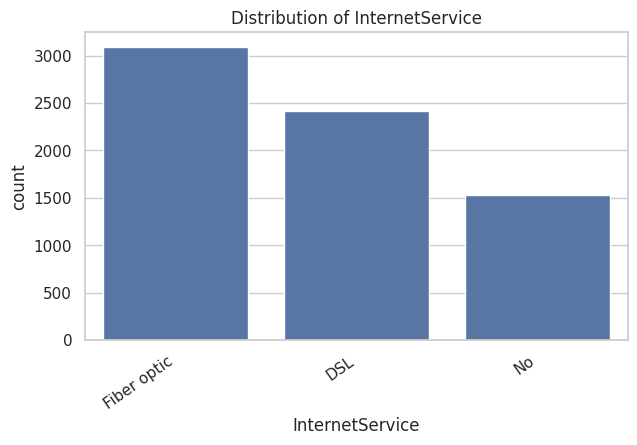

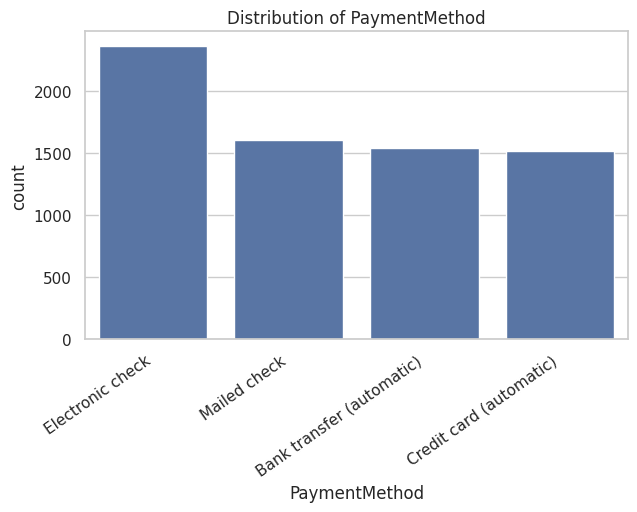

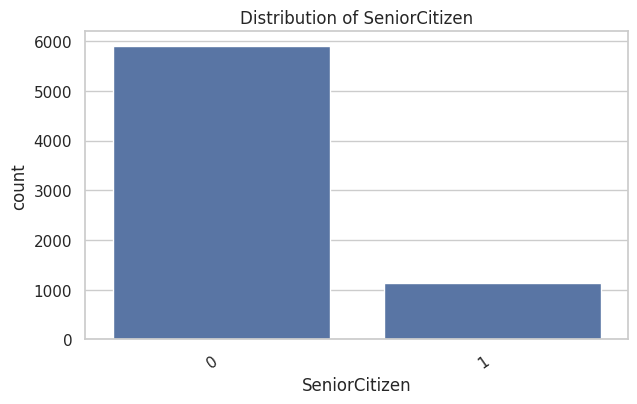

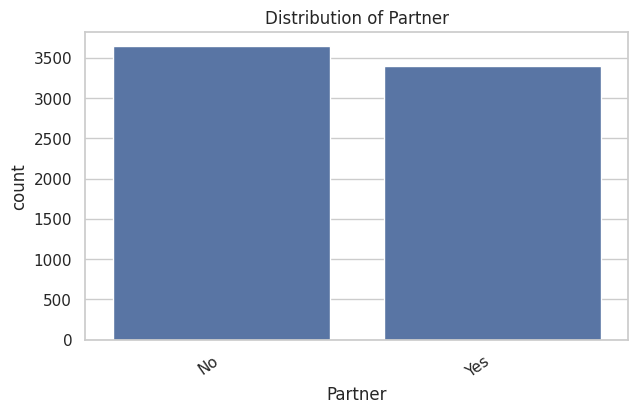

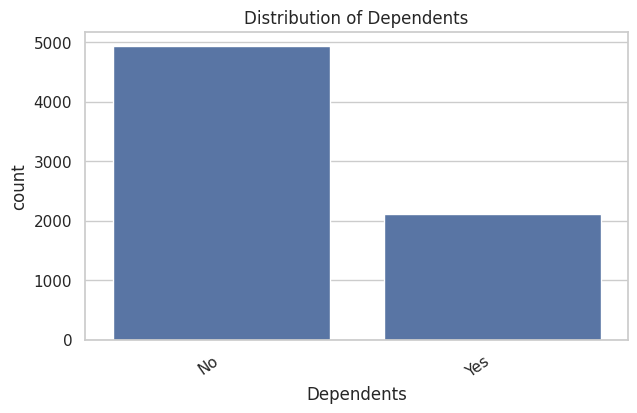

In [10]:
categorical_for_eda = [
    "Contract", "InternetService", "PaymentMethod",
    "SeniorCitizen", "Partner", "Dependents"
]

for col in categorical_for_eda:
    plt.figure(figsize=(7, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=35, ha="right")
    plt.show()


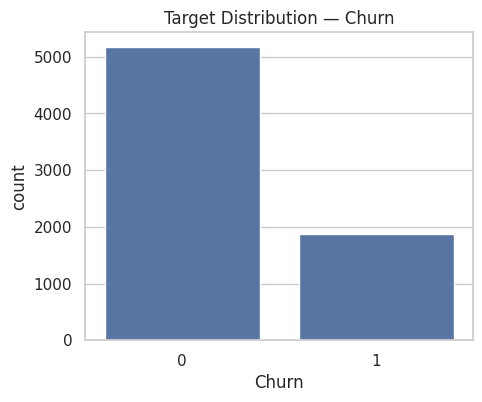

Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn")
plt.title("Target Distribution — Churn")
plt.show()

print(df["Churn"].value_counts(normalize=True).mul(100).round(2))


## 4. Bivariate EDA — churn drivers

For categorical variables, compare the **churn rate** rather than only the number of customers. This makes comparisons fair across categories.


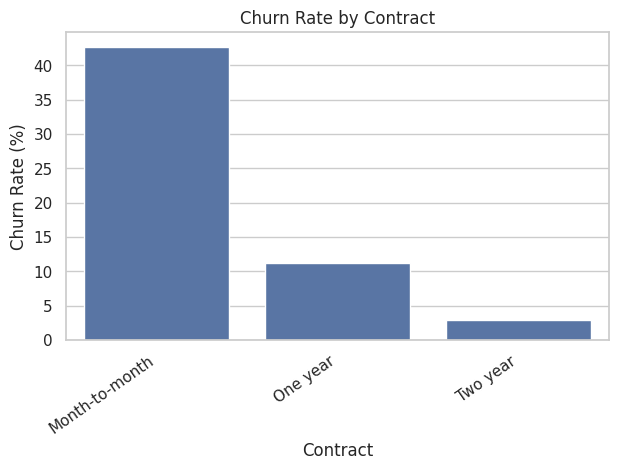

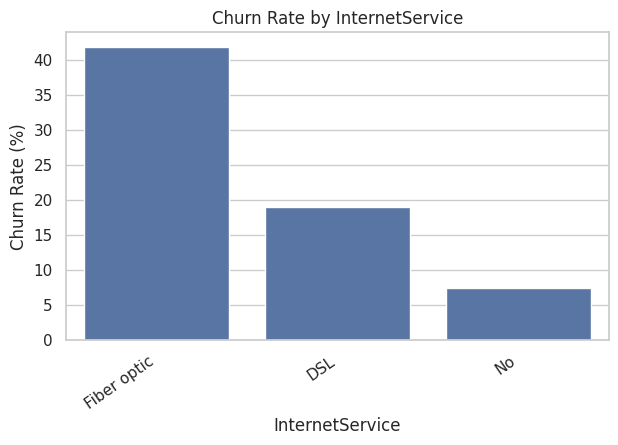

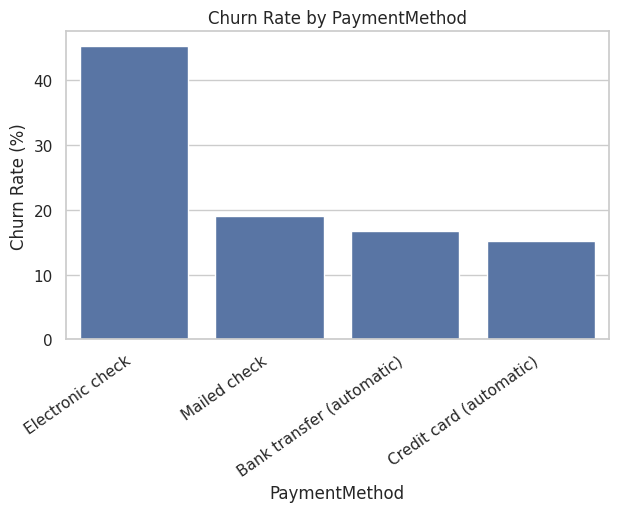

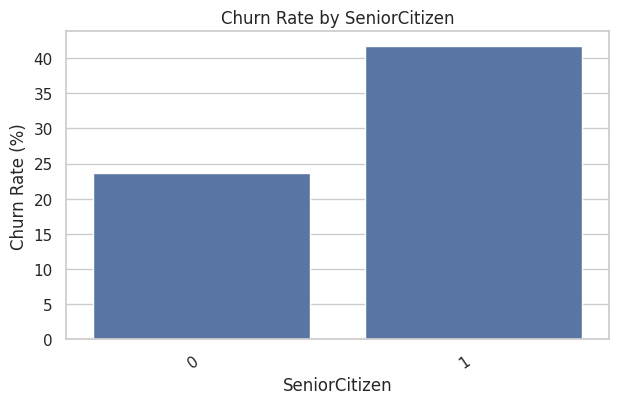

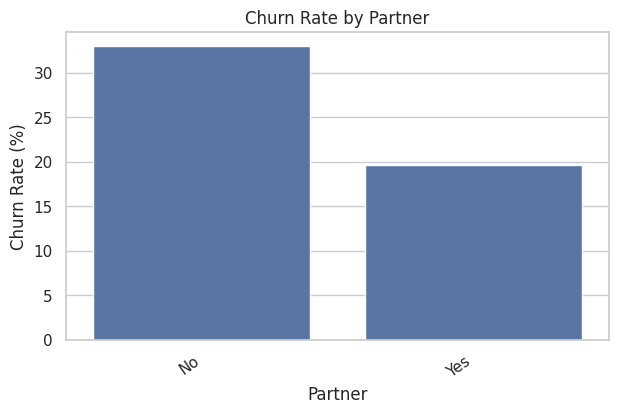

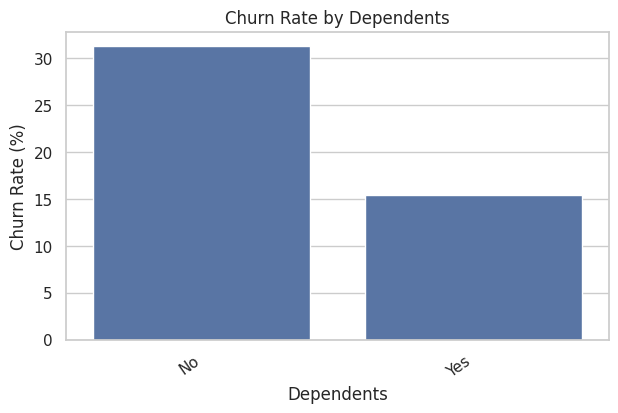

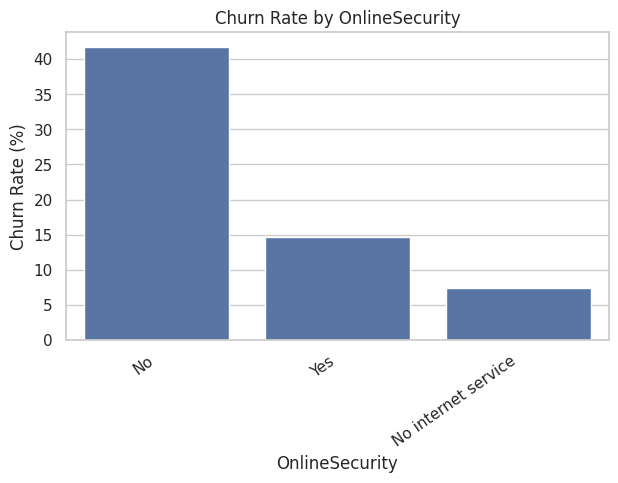

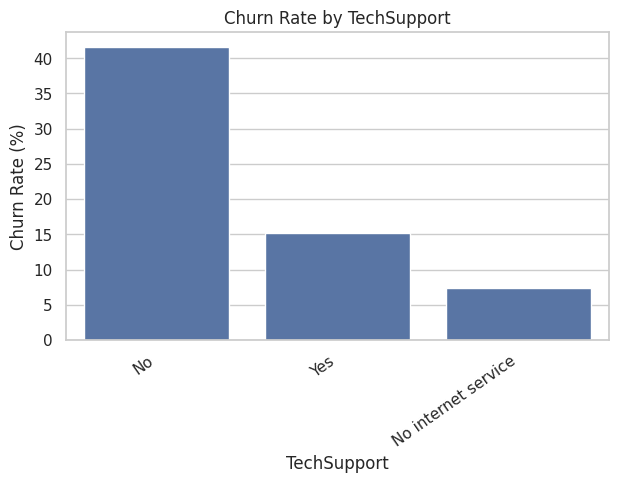

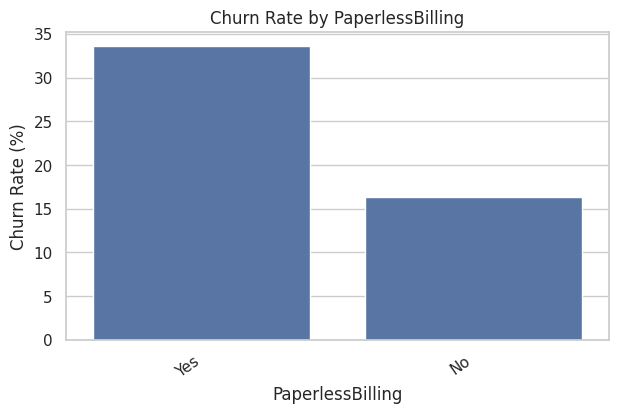

In [12]:
bivariate_cats = [
    "Contract", "InternetService", "PaymentMethod",
    "SeniorCitizen", "Partner", "Dependents",
    "OnlineSecurity", "TechSupport", "PaperlessBilling"
]

for col in bivariate_cats:
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False).mul(100)
    plt.figure(figsize=(7, 4))
    sns.barplot(x=churn_rate.index, y=churn_rate.values)
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=35, ha="right")
    plt.show()


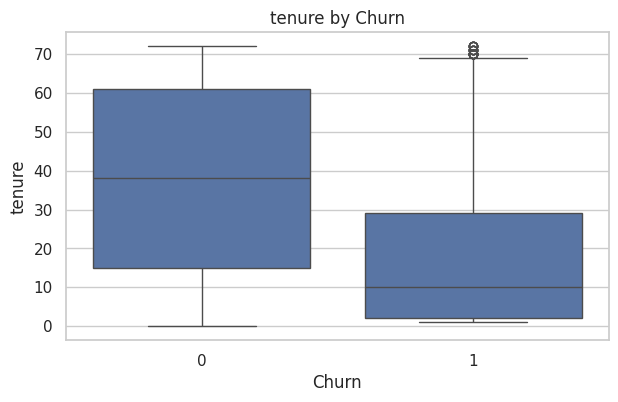

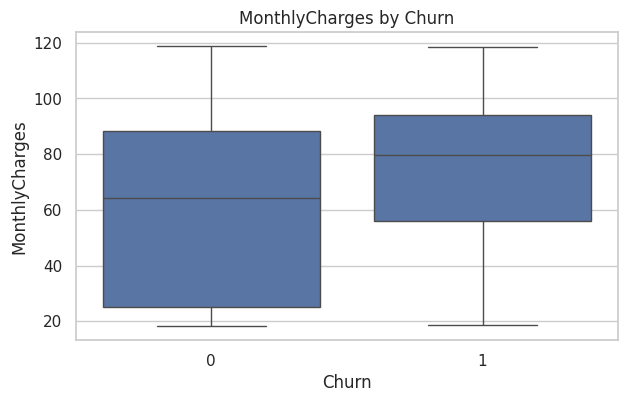

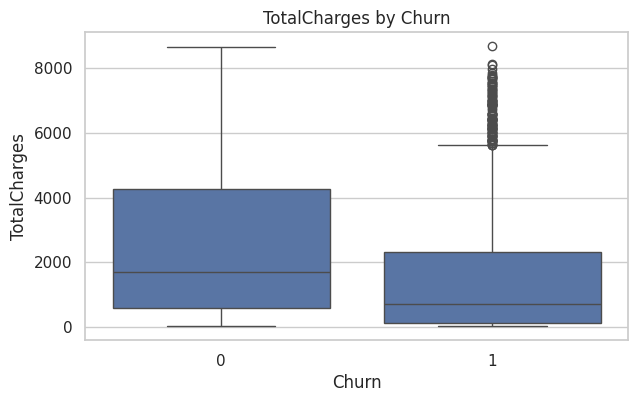

In [13]:
# Numerical variables vs churn
for col in numeric_for_eda:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} by Churn")
    plt.show()


In [14]:
# A compact table of important bivariate insights
for col in ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport"]:
    print(f"\n{col}")
    display(
        df.groupby(col)["Churn"]
          .agg(["count", "mean"])
          .rename(columns={"mean": "churn_rate"})
          .assign(churn_rate=lambda x: (x["churn_rate"]*100).round(2))
          .sort_values("churn_rate", ascending=False)
    )



Contract


,count,churn_rate
Contract,,
Month-to-month,3875,42.71
One year,1473,11.27
Two year,1695,2.83



InternetService


,count,churn_rate
InternetService,,
Fiber optic,3096,41.89
DSL,2421,18.96
No,1526,7.40



PaymentMethod


,count,churn_rate
PaymentMethod,,
Electronic check,2365,45.29
Mailed check,1612,19.11
Bank transfer (automatic),1544,16.71
Credit card (automatic),1522,15.24



OnlineSecurity


,count,churn_rate
OnlineSecurity,,
No,3498,41.77
Yes,2019,14.61
No internet service,1526,7.40



TechSupport


,count,churn_rate
TechSupport,,
No,3473,41.64
Yes,2044,15.17
No internet service,1526,7.40


### Key EDA observations

- **Contract type:** Month-to-month customers had a 42.71% churn rate, compared with 11.27% for one-year contracts and 2.83% for two-year contracts.
- **Internet service:** Fiber-optic customers had a 41.89% churn rate, compared with 18.96% for DSL and 7.40% for customers without internet service.
- **Payment method:** Electronic-check customers had a 45.29% churn rate, compared with 16.71% for customers using automatic bank transfer.
- **Online security:** Customers without online security had a 41.77% churn rate versus 14.61% for customers with the service.
- **Technical support:** Customers without technical support had a 41.64% churn rate versus 15.17% for customers with the service.

These are associations observed in the dataset, not causal effects.


## 5. Feature engineering

We create a small number of business-meaningful features rather than generating many arbitrary columns.

- `TotalServices`: number of subscribed add-on/service features.
- `AvgMonthlySpend`: total charges divided by tenure, with a safe denominator.
- `TenureGroup`: customer lifecycle bucket.
- `IsLongTermContract`: whether the customer has a one/two-year contract.


In [15]:
# Work on a copy
model_df = df.copy()

service_cols = [
    "PhoneService", "MultipleLines", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]

# Count meaningful active services (Yes only)
model_df["TotalServices"] = (model_df[service_cols] == "Yes").sum(axis=1)

# Avoid division by zero
model_df["AvgMonthlySpend"] = (
    model_df["TotalCharges"] / model_df["tenure"].replace(0, np.nan)
)

model_df["TenureGroup"] = pd.cut(
    model_df["tenure"],
    bins=[-1, 12, 24, 48, np.inf],
    labels=["0-12", "13-24", "25-48", "49+"]
)

model_df["IsLongTermContract"] = (
    model_df["Contract"].isin(["One year", "Two year"]).astype(int)
)

display(model_df[[
    "tenure", "TotalCharges", "TotalServices",
    "AvgMonthlySpend", "TenureGroup", "IsLongTermContract", "Churn"
]].head())


,tenure,TotalCharges,TotalServices,AvgMonthlySpend,TenureGroup,IsLongTermContract,Churn
0,1,29.85,1,29.850000,0-12,0,0
1,34,1889.50,3,55.573529,25-48,1,0
2,2,108.15,3,54.075000,0-12,0,1
3,45,1840.75,3,40.905556,25-48,1,0
4,2,151.65,1,75.825000,0-12,0,1


## 6. Outlier analysis

We use the IQR rule to **detect** possible outliers. We do not automatically delete them because an unusually high telecom bill can be a legitimate customer observation.

The final decision should be based on data understanding and validation performance.


In [16]:
outlier_cols = ["tenure", "MonthlyCharges", "TotalCharges", "TotalServices", "AvgMonthlySpend"]

outlier_summary = []

for col in outlier_cols:
    s = model_df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    count = ((s < lower) | (s > upper)).sum()
    outlier_summary.append([col, q1, q3, lower, upper, count, count/len(s)*100])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=["feature", "Q1", "Q3", "lower", "upper", "outlier_count", "outlier_pct"]
)

display(outlier_summary.round(2))


,feature,Q1,Q3,lower,upper,outlier_count,outlier_pct
0,tenure,9.00,55.00,-60.00,124.00,0,0.0
1,MonthlyCharges,35.50,89.85,-46.02,171.38,0,0.0
2,TotalCharges,401.45,3794.74,-4688.48,8884.67,0,0.0
3,TotalServices,1.00,5.00,-5.00,11.00,0,0.0
4,AvgMonthlySpend,36.18,90.18,-44.82,171.18,0,0.0


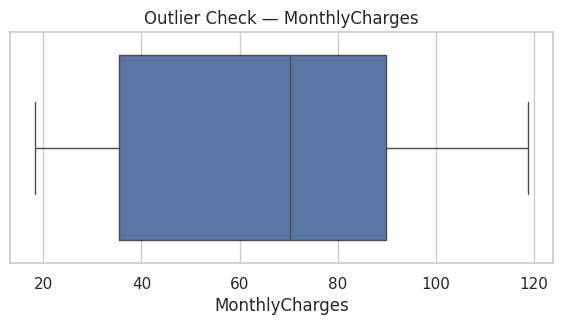

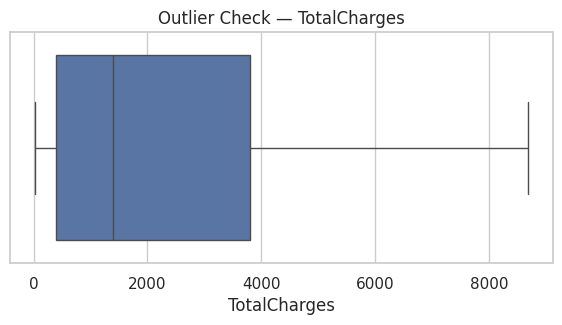

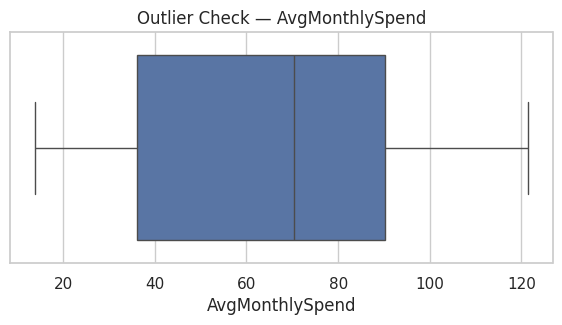

In [17]:
for col in ["MonthlyCharges", "TotalCharges", "AvgMonthlySpend"]:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=model_df[col])
    plt.title(f"Outlier Check — {col}")
    plt.show()


## 7. Train/test split

We split before fitting any imputer, encoder or scaler. The split is stratified so that the churn proportion is approximately preserved in both sets.


In [18]:
X = model_df.drop(columns=["Churn", "customerID"])
y = model_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("Train churn rate:", round(y_train.mean()*100, 2), "%")
print("Test churn rate :", round(y_test.mean()*100, 2), "%")


Train: (5634, 23)
Test : (1409, 23)
Train churn rate: 26.54 %
Test churn rate : 26.54 %


## 8. Preprocessing pipeline

We use separate transformations for numerical and categorical columns.

### Numerical
Median imputation → StandardScaler

### Categorical
Most-frequent imputation → OneHotEncoder

Putting preprocessing inside the pipeline prevents information from the test set leaking into training.


In [19]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)


Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'AvgMonthlySpend', 'IsLongTermContract']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


## 9. Model selection

We intentionally compare different model families:

- **Logistic Regression** — interpretable linear baseline
- **Decision Tree** — non-linear model
- **Random Forest** — bagging ensemble
- **XGBoost** — gradient boosting ensemble

This is enough to make a meaningful comparison without training an unnecessarily large number of algorithms.


In [20]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=3,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1
    )
}

pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}


## 10. Cross-validation model comparison

Because churn is imbalanced, we track **Recall, F1, ROC-AUC and PR-AUC** instead of relying only on accuracy.

`PR-AUC` is particularly useful when the positive class (churn) is the class we care about identifying.


In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_rows = []

for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1
    )

    row = {"Model": name}
    for metric in scoring:
        row[metric.upper()] = scores[f"test_{metric}"].mean()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values("PR_AUC", ascending=False)
display(cv_results.round(4))


,Model,ACCURACY,PRECISION,RECALL,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.7504,0.5194,0.7987,0.6293,0.8458,0.6618
3,XGBoost,0.7994,0.6545,0.5184,0.5781,0.8430,0.6584
2,Random Forest,0.7852,0.5821,0.6763,0.6255,0.8421,0.6518
1,Decision Tree,0.7432,0.5110,0.7793,0.6167,0.8313,0.6201


## 11. Train the candidate models on the full training set

We now fit every selected model on the training data and evaluate it once on the untouched test set.


In [22]:
test_rows = []
fitted_models = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    prob = pipe.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    test_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob),
        "PR_AUC": average_precision_score(y_test, prob)
    })

test_results = pd.DataFrame(test_rows).sort_values("PR_AUC", ascending=False)
display(test_results.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
3,XGBoost,0.8041,0.6678,0.5214,0.5856,0.8419,0.6523
2,Random Forest,0.7764,0.5666,0.6711,0.6144,0.8371,0.6374
0,Logistic Regression,0.7346,0.5000,0.7941,0.6136,0.8419,0.6350
1,Decision Tree,0.7559,0.5279,0.7594,0.6228,0.8332,0.6251


## 12. Hyperparameter tuning

We tune the two important tree ensembles. The search optimizes **PR-AUC** because identifying churners is the main objective.


In [23]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    ))
])

rf_params = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 4, 6, 8, 12],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_params, n_iter=20,
    scoring="average_precision", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_search.best_params_)
print("Best CV PR-AUC:", round(rf_search.best_score_, 4))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Random Forest parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 20, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 8}
Best CV PR-AUC: 0.666


In [24]:
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_params = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5, 10]
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_params, n_iter=20,
    scoring="average_precision", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)
print("Best CV PR-AUC:", round(xgb_search.best_score_, 4))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGBoost parameters:
{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 4, 'model__learning_rate': 0.02, 'model__colsample_bytree': 1.0}
Best CV PR-AUC: 0.6701


## 13. Final model selection

The final model is selected using cross-validation on the training data, with **PR-AUC as the primary ranking metric**. The test set remains untouched until final evaluation.


In [33]:
# ---------------------------------------------------------
# FINAL MODEL SELECTION USING CROSS-VALIDATION
# ---------------------------------------------------------

# Evaluate the tuned models using CV on the training data.
# The test set is NOT used for selecting the final model.

tuned_cv_rows = []

for name, pipe in tuned_models.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    tuned_cv_rows.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC_AUC": scores["test_roc_auc"].mean(),
        "PR_AUC": scores["test_pr_auc"].mean()
    })

tuned_cv_results = pd.DataFrame(tuned_cv_rows)

display(
    tuned_cv_results
    .sort_values("PR_AUC", ascending=False)
    .round(4)
)

# Select final model using CV PR-AUC
best_row = tuned_cv_results.sort_values(
    "PR_AUC", ascending=False
).iloc[0]

best_name = best_row["Model"]
best_model = tuned_models[best_name]

print("Selected final model based on CV PR-AUC:", best_name)
print("CV PR-AUC:", round(best_row["PR_AUC"], 4))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
1,Tuned XGBoost,0.8042,0.6644,0.5304,0.5896,0.8488,0.6701
0,Tuned Random Forest,0.7632,0.5380,0.7726,0.6339,0.8476,0.6660


Selected final model based on CV PR-AUC: Tuned XGBoost
CV PR-AUC: 0.6701


## 14. Threshold optimization

A default probability threshold of 0.50 is not always appropriate for churn prediction. We select the threshold using out-of-fold predictions from the training data and maximize F1, then lock that threshold before evaluating on the unseen test set.


In [36]:
# ---------------------------------------------------------
# THRESHOLD SELECTION USING OUT-OF-FOLD PREDICTIONS
# ---------------------------------------------------------

# Generate probabilities using cross-validation on training data.
# This gives predictions for observations that were not used
# to train the model in their respective fold.

oof_prob = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):

    pred = (oof_prob >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": round(float(threshold), 2),
        "Precision": precision_score(
            y_train, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_train, pred, zero_division=0
        ),
        "F1": f1_score(
            y_train, pred, zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_rows)

display(threshold_results.round(3))

# Select threshold based on maximum F1
best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

recommended_threshold = best_threshold_row["Threshold"]

print(
    "Recommended threshold based on training cross-validation:",
    recommended_threshold
)


,Threshold,Precision,Recall,F1
0,0.10,0.404,0.936,0.564
1,0.15,0.447,0.896,0.596
2,0.20,0.482,0.858,0.617
3,0.25,0.511,0.809,0.626
4,0.30,0.544,0.761,0.635
5,0.35,0.575,0.708,0.635
6,0.40,0.619,0.643,0.631
7,0.45,0.648,0.592,0.619
8,0.50,0.664,0.530,0.590
9,0.55,0.689,0.460,0.552


Recommended threshold based on training cross-validation: 0.3


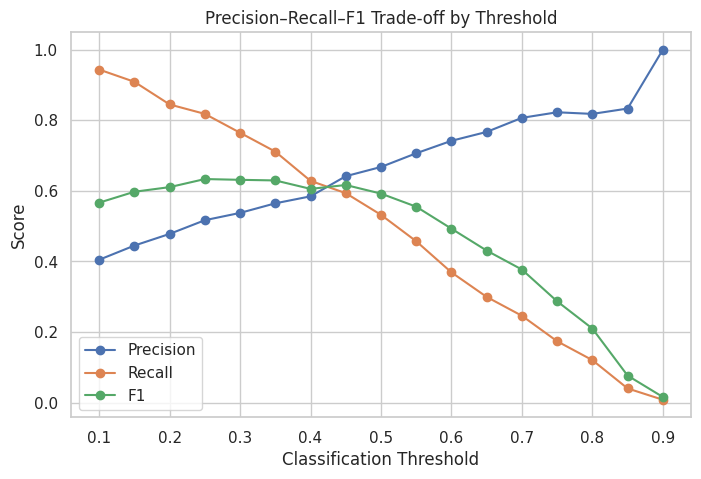

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results["Threshold"], threshold_results["Precision"], marker="o", label="Precision")
plt.plot(threshold_results["Threshold"], threshold_results["Recall"], marker="o", label="Recall")
plt.plot(threshold_results["Threshold"], threshold_results["F1"], marker="o", label="F1")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall–F1 Trade-off by Threshold")
plt.legend()
plt.show()


In [38]:
# ---------------------------------------------------------
# FINAL MODEL EVALUATION ON UNSEEN TEST DATA
# ---------------------------------------------------------

# Fit the selected model on the complete training set
best_model.fit(X_train, y_train)

# Predict churn probabilities on the untouched test set
final_test_prob = best_model.predict_proba(X_test)[:, 1]

# Apply threshold selected using training CV
final_test_pred = (
    final_test_prob >= recommended_threshold
).astype(int)

print("Final Model:", best_name)
print("Final Threshold:", recommended_threshold)

print("\nFinal Test Classification Report:")

print(
    classification_report(
        y_test,
        final_test_pred,
        target_names=["Not Churn", "Churn"],
        zero_division=0
    )
)

Final Model: Tuned XGBoost
Final Threshold: 0.3

Final Test Classification Report:
              precision    recall  f1-score   support

   Not Churn       0.90      0.76      0.83      1035
       Churn       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [39]:
# ---------------------------------------------------------
# FINAL TEST METRICS
# ---------------------------------------------------------

final_metrics = {
    "Model": best_name,
    "Threshold": recommended_threshold,
    "Accuracy": accuracy_score(
        y_test,
        final_test_pred
    ),
    "Precision": precision_score(
        y_test,
        final_test_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        final_test_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        final_test_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        final_test_prob
    ),
    "PR_AUC": average_precision_score(
        y_test,
        final_test_prob
    )
}

final_metrics_df = pd.DataFrame([final_metrics])

display(
    final_metrics_df.round(4)
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned XGBoost,0.3,0.763,0.5376,0.7647,0.6313,0.8472,0.6619


### Choosing the threshold

For a placement project, do not simply say "the best threshold is X".

Instead explain the business trade-off:

- Lower threshold → catches more potential churners → higher recall, but more false alarms.
- Higher threshold → fewer false alarms → higher precision, but may miss churners.

The final threshold should therefore depend on the **relative cost of false negatives vs false positives**.


## 15. Final evaluation on unseen test data


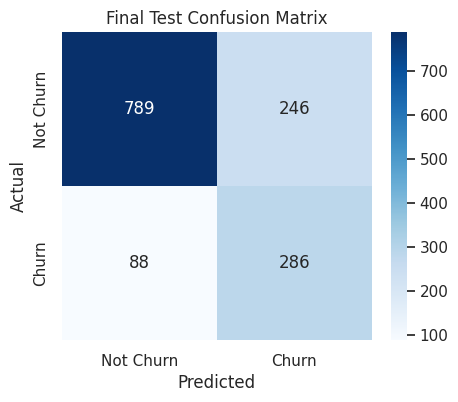

In [41]:
# ---------------------------------------------------------
# FINAL TEST CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(
    y_test,
    final_test_pred
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Test Confusion Matrix")

plt.show()


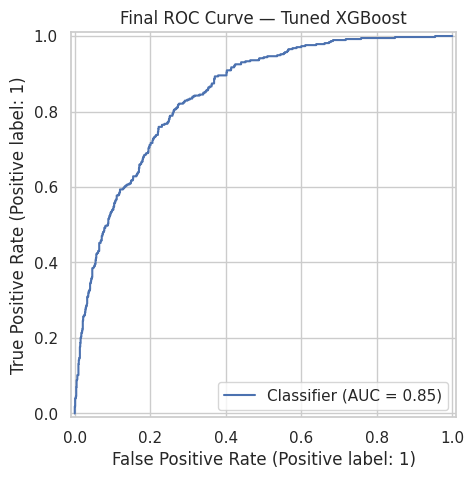

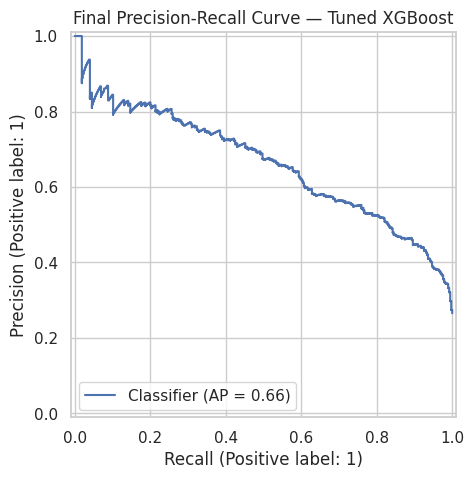

In [42]:
# ---------------------------------------------------------
# FINAL ROC CURVE
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    final_test_prob,
    ax=ax
)

ax.set_title(
    f"Final ROC Curve — {best_name}"
)

plt.show()


# ---------------------------------------------------------
# FINAL PRECISION-RECALL CURVE
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    final_test_prob,
    ax=ax
)

ax.set_title(
    f"Final Precision-Recall Curve — {best_name}"
)

plt.show()


## 16. Feature importance / interpretability

Feature importance is used to connect model predictions with business interpretation. It indicates predictive usefulness, not causality.


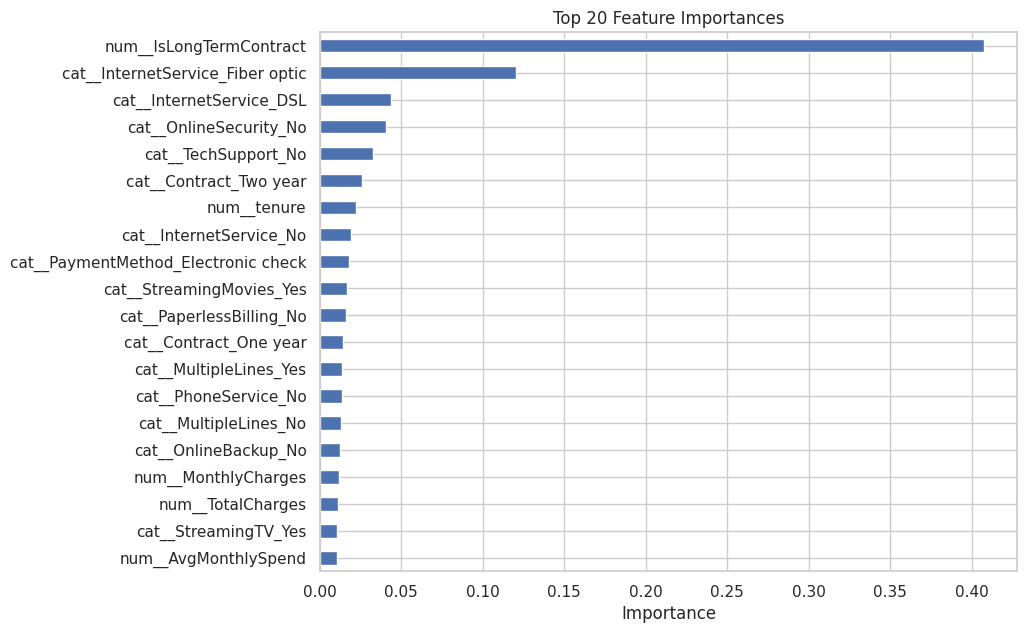

,importance
num__IsLongTermContract,0.407610
cat__InternetService_Fiber optic,0.120641
cat__InternetService_DSL,0.043558
cat__OnlineSecurity_No,0.040443
cat__TechSupport_No,0.032456
cat__Contract_Two year,0.025887
num__tenure,0.022370
cat__InternetService_No,0.019198
cat__PaymentMethod_Electronic check,0.017653
cat__StreamingMovies_Yes,0.016821


In [43]:
# Extract feature names after preprocessing
pre = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

feature_names = pre.get_feature_names_out()

if hasattr(model, "feature_importances_"):
    importance = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False).head(20)

    plt.figure(figsize=(9, 7))
    importance.sort_values().plot(kind="barh")
    plt.title("Top 20 Feature Importances")
    plt.xlabel("Importance")
    plt.show()

    display(importance.to_frame("importance"))
else:
    print("Feature importance is not available for this final model.")


## 17. Business conclusions

### Key EDA insights

The analysis shows clear differences in churn rates across contract type, internet service, payment method, online security and technical support. These relationships are predictive associations rather than causal effects.

### Final model result

The tuned XGBoost model achieved the highest training cross-validation PR-AUC (**0.6701**) among the tuned ensemble candidates. A threshold of **0.30** was selected using training cross-validation by maximizing F1.

On the untouched test set, the final model achieved:

- **Accuracy:** 76.3%
- **Precision:** 53.7%
- **Recall:** 76.5%
- **F1:** 63.1%
- **ROC-AUC:** 84.72%
- **PR-AUC:** 66.19%

### Business interpretation

The 0.30 threshold prioritizes identifying more potential churners rather than relying on the default 0.50 threshold. This can support targeted retention campaigns, where missing a likely churner may be more costly than contacting some customers who ultimately remain.

Feature importance highlights contract structure, internet service and support/security-related variables as important predictive signals.


## 18. Project summary

### Technical skills demonstrated

- Exploratory Data Analysis
- Missing-value handling
- Categorical encoding
- Feature engineering
- Outlier analysis
- Data preprocessing pipelines
- Logistic Regression
- Decision Trees
- Random Forest
- XGBoost
- Ensemble learning
- Stratified cross-validation
- Hyperparameter tuning
- Imbalanced classification evaluation
- ROC-AUC and PR-AUC
- Precision / Recall / F1
- Classification threshold optimization
- Feature importance and business interpretation

### Key placement takeaway

> The final model was selected using cross-validation rather than test-set performance. Because churn is the business target and the classes are imbalanced, PR-AUC, Recall, Precision and F1 were considered alongside ROC-AUC. The classification threshold was optimized using training cross-validation before the final evaluation on unseen test data.
